# Chatbot with HITL (Human in the Loop)

Agent 처리도중 사람의 개입이 필요한 경우 iterrupt처리할 수 있다.
- 사람의 개입(tool)
- 사람 메세지(command)로 대화를 재개할 수 있다.

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

In [2]:
# Tavily 도구 생성
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=3)

### 사람 개입 도구

In [3]:
from langchain_core.tools import tool # Tool 데코레이터 
from langgraph.types import interrupt # 사람응답을 기다리는 interrupt

@tool
def human_assist(query):
    """ 사람의 개입이 필요하면 이 도구를 사용합니다."""
    human_response = interrupt({'query':query}) # 사람의 응답이 올때까지 입력 대기
    return human_response['data'] # 사람의 응답 데이터

In [4]:
from typing import TypedDict, Annotated, List # 타입 힌트 도구
from langgraph.graph.message import add_messages # 메세지 누적 처리를 해줄 헬퍼
from langchain.chat_models import init_chat_model

# 그래프에서 사용할 상태(TypedDict) 스키마
class State(TypedDict):
    messages : Annotated[List, add_messages] # messages 필드가 add_messages 규칙으로 누적 저장

llm = init_chat_model('gpt-5.4-mini')
tools = [tavily_tool, human_assist]
llm_with_tools = llm.bind_tools(tools) # llm에 도구 스펙 파인딩

# State의 messages를 입력 받아, 응답 메세지를 추가해주는 노드 함수
def chatbot(state: State):
    response = llm_with_tools.invoke(state['messages']) # 누적된 메세지 리스트로 LLM 호출
    return {'messages' : [response]} # add_messages 규칙에 의해 기존 messages에 응답이 누적됨

In [5]:
# 메모리 기반 체크포인트 저장소 (인메모리)
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver() # 상태 체크포인트를 RAM에 저장하는 객체

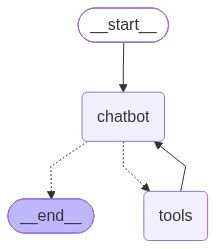

In [6]:
# 직접 구현한 ToolNode와 tools_condition 함수 사용한 워크플로우
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

builder = StateGraph(State) # State 스키마 기반 그래프 설계 객체 생성
tool_node = ToolNode(tools)

builder.add_edge(START, 'chatbot') # START -> chatbot

builder.add_node('chatbot', chatbot)     # chatbot
builder.add_node('tools', tool_node)     # tools

builder.add_conditional_edges('chatbot', tools_condition)
builder.add_edge('tools', 'chatbot')

graph = builder.compile(checkpointer=memory) # checkpointer를 포함하여 실행 가능한 그래프로 컴파일
graph

### 챗봇 실행

In [16]:
from pprint import pprint

# 스냅샷 출력 함수 : 저장된 상태(messages)와 다음 실행 노드(next) 확인
def print_snapshot(graph, config):
    snapshot = graph.get_state(config) # 해당 config(thread_id)의 스냅샷 조회
    if 'messages' in snapshot.values:
        pprint(snapshot.values['messages'])
    else:
        print('메시지가 없음!')
    print(f"Next: {snapshot.next}")

print(print_snapshot(graph,{'configurable': {'thread_id': 'user1'}}))


[HumanMessage(content='langgraph를 멀티에이전트 설계에서 사용하는 이유가 뭐야?', additional_kwargs={}, response_metadata={}, id='92a3c002-fc92-40c4-aa89-432a667dd702'),
 AIMessage(content='LangGraph를 멀티에이전트 설계에서 쓰는 이유는, **에이전트 간 상호작용을 “그냥 대화”가 아니라 “명시적인 상태 머신/그래프”로 제어할 수 있기 때문**이에요.\n\n핵심 이유만 정리하면:\n\n1. **흐름 제어가 명확함**\n   - 어떤 에이전트가 언제 실행되고, 다음에 누구에게 넘길지, 종료 조건이 뭔지\n   - 이런 걸 코드 레벨에서 그래프로 정의할 수 있어서 복잡한 협업 구조를 관리하기 좋습니다.\n\n2. **상태(State) 관리가 쉬움**\n   - 멀티에이전트는 공통 메모리, 중간 결과, 작업 진행 상태가 중요합니다.\n   - LangGraph는 노드 간에 상태를 전달/갱신하는 구조라서, 에이전트들이 같은 작업 맥락을 유지하기 좋습니다.\n\n3. **분기/루프/재시도에 강함**\n   - 멀티에이전트 시스템은\n     - 검증 후 재작성\n     - 실패 시 다른 에이전트로 넘기기\n     - 조건부 분기\n     - 반복 협의\n     같은 패턴이 많아요.\n   - LangGraph는 이런 제어 흐름을 자연스럽게 표현할 수 있습니다.\n\n4. **역할 분담이 선명함**\n   - 예: planner / researcher / coder / reviewer 같은 역할을 각각 노드로 분리 가능\n   - 각 에이전트의 책임이 분명해져서 디버깅과 확장이 쉬워집니다.\n\n5. **관찰성과 디버깅이 좋음**\n   - “왜 이런 결과가 나왔지?”를 보기 위해서는 실행 경로가 중요해요.\n   - 그래프 구조면 어떤 노드를 거쳤는지 추적하기 쉬워서 운영/개선에 유리합니다.\n\n6. **복잡한 오케스트레이션에 적합**\n   

In [8]:
user1_config = {'configurable': {'thread_id': 'user1'}}
state = {'messages': [('human','langgraph를 멀티에이전트 설계에서 사용하는 이유가 뭐야?')]}

response = graph.invoke(state, user1_config) # 그래프 비동기 실행
print(response['messages'][-1].content)

LangGraph를 멀티에이전트 설계에서 쓰는 이유는, **에이전트 간 상호작용을 “그냥 대화”가 아니라 “명시적인 상태 머신/그래프”로 제어할 수 있기 때문**이에요.

핵심 이유만 정리하면:

1. **흐름 제어가 명확함**
   - 어떤 에이전트가 언제 실행되고, 다음에 누구에게 넘길지, 종료 조건이 뭔지
   - 이런 걸 코드 레벨에서 그래프로 정의할 수 있어서 복잡한 협업 구조를 관리하기 좋습니다.

2. **상태(State) 관리가 쉬움**
   - 멀티에이전트는 공통 메모리, 중간 결과, 작업 진행 상태가 중요합니다.
   - LangGraph는 노드 간에 상태를 전달/갱신하는 구조라서, 에이전트들이 같은 작업 맥락을 유지하기 좋습니다.

3. **분기/루프/재시도에 강함**
   - 멀티에이전트 시스템은
     - 검증 후 재작성
     - 실패 시 다른 에이전트로 넘기기
     - 조건부 분기
     - 반복 협의
     같은 패턴이 많아요.
   - LangGraph는 이런 제어 흐름을 자연스럽게 표현할 수 있습니다.

4. **역할 분담이 선명함**
   - 예: planner / researcher / coder / reviewer 같은 역할을 각각 노드로 분리 가능
   - 각 에이전트의 책임이 분명해져서 디버깅과 확장이 쉬워집니다.

5. **관찰성과 디버깅이 좋음**
   - “왜 이런 결과가 나왔지?”를 보기 위해서는 실행 경로가 중요해요.
   - 그래프 구조면 어떤 노드를 거쳤는지 추적하기 쉬워서 운영/개선에 유리합니다.

6. **복잡한 오케스트레이션에 적합**
   - 단일 에이전트로는 벅찬 작업을 여러 에이전트로 나누고,
   - 이를 중앙에서 조율하는 형태에 잘 맞습니다.
   - 특히 도구 호출, 인간 승인, 에러 처리까지 포함된 워크플로우에 강합니다.

### 한 줄 요약
**LangGraph는 멀티에이전트를 “자율 대화 시스템”이 아니라 “통제 가능한 협업 워크플로우”로 만들기 위해 사용합니다.**

원하면

In [9]:
print_snapshot(graph, user1_config)

[HumanMessage(content='langgraph를 멀티에이전트 설계에서 사용하는 이유가 뭐야?', additional_kwargs={}, response_metadata={}, id='92a3c002-fc92-40c4-aa89-432a667dd702'), AIMessage(content='LangGraph를 멀티에이전트 설계에서 쓰는 이유는, **에이전트 간 상호작용을 “그냥 대화”가 아니라 “명시적인 상태 머신/그래프”로 제어할 수 있기 때문**이에요.\n\n핵심 이유만 정리하면:\n\n1. **흐름 제어가 명확함**\n   - 어떤 에이전트가 언제 실행되고, 다음에 누구에게 넘길지, 종료 조건이 뭔지\n   - 이런 걸 코드 레벨에서 그래프로 정의할 수 있어서 복잡한 협업 구조를 관리하기 좋습니다.\n\n2. **상태(State) 관리가 쉬움**\n   - 멀티에이전트는 공통 메모리, 중간 결과, 작업 진행 상태가 중요합니다.\n   - LangGraph는 노드 간에 상태를 전달/갱신하는 구조라서, 에이전트들이 같은 작업 맥락을 유지하기 좋습니다.\n\n3. **분기/루프/재시도에 강함**\n   - 멀티에이전트 시스템은\n     - 검증 후 재작성\n     - 실패 시 다른 에이전트로 넘기기\n     - 조건부 분기\n     - 반복 협의\n     같은 패턴이 많아요.\n   - LangGraph는 이런 제어 흐름을 자연스럽게 표현할 수 있습니다.\n\n4. **역할 분담이 선명함**\n   - 예: planner / researcher / coder / reviewer 같은 역할을 각각 노드로 분리 가능\n   - 각 에이전트의 책임이 분명해져서 디버깅과 확장이 쉬워집니다.\n\n5. **관찰성과 디버깅이 좋음**\n   - “왜 이런 결과가 나왔지?”를 보기 위해서는 실행 경로가 중요해요.\n   - 그래프 구조면 어떤 노드를 거쳤는지 추적하기 쉬워서 운영/개선에 유리합니다.\n\n6. **복잡한 오케스트레이션에 적합**\n   -

### 케이크샵 챗봇

In [12]:
from langchain_core.prompts import ChatPromptTemplate

system_prompt = """
**Instruction**
사용자는 케이크 주문, 메뉴 문의, 매장 정보 등을 챗봇에 요청할 수 있다.
챗봇은 친절하고 정확하게 답변한다.

**Context**
당신은 프리미엄 케이크샵의 공식 챗봇이다.
- 운영 시간: 매일 09:00–21:00
- 주요 메뉴: 생크림 케이크, 초코 케이크, 치즈 케이크, 시즌 한정 케이크
- 매장 위치: 서울 강남구 신사동 123-45
- 연락처: 02-1234-5678

**Example**
> **User:** “다음 주 수요일 오후 3시에 케이크 예약 가능한가요?”
> **Bot:** “안녕하세요! 다음 주 수요일(2025년 7월 16일) 오후 3시에 예약 가능합니다. 예약을 원하시면 성함과 연락처를 알려주세요.”

**Output Indicator**
- 챗봇 응답은 한 문단 이내로 간결하게 제시한다.
- 필요한 경우 날짜·시간은 YYYY년 M월 D일 형식으로 명시한다.
- 추가 질문이 필요할 때에는 “추가로 궁금하신 점이 있으면 말씀해주세요.” 로 마무리한다.
- 그외 답변하기 어려운 경우, human_assist 도구를 사용하여 인간의 도움을 요청한다.
"""  # 시스템 지침/컨텍스트/출력 규칙 정의

user_prompt = '당근케익 4호가 홈페이지에서 구매가 안되는데, 매니져님께 구매가능여부를 묻고 싶어요.'  # 사용자 요청 문장

prompt = ChatPromptTemplate.from_messages([
    ('system', system_prompt),
    ('human', '{user_prompt}')
])

state = {'messages': prompt.format_messages(user_prompt= user_prompt)}

response = graph.invoke(state, user1_config)
print(response['messages'][-1].content)

In [13]:
print_snapshot(graph, user1_config)

[HumanMessage(content='langgraph를 멀티에이전트 설계에서 사용하는 이유가 뭐야?', additional_kwargs={}, response_metadata={}, id='92a3c002-fc92-40c4-aa89-432a667dd702'), AIMessage(content='LangGraph를 멀티에이전트 설계에서 쓰는 이유는, **에이전트 간 상호작용을 “그냥 대화”가 아니라 “명시적인 상태 머신/그래프”로 제어할 수 있기 때문**이에요.\n\n핵심 이유만 정리하면:\n\n1. **흐름 제어가 명확함**\n   - 어떤 에이전트가 언제 실행되고, 다음에 누구에게 넘길지, 종료 조건이 뭔지\n   - 이런 걸 코드 레벨에서 그래프로 정의할 수 있어서 복잡한 협업 구조를 관리하기 좋습니다.\n\n2. **상태(State) 관리가 쉬움**\n   - 멀티에이전트는 공통 메모리, 중간 결과, 작업 진행 상태가 중요합니다.\n   - LangGraph는 노드 간에 상태를 전달/갱신하는 구조라서, 에이전트들이 같은 작업 맥락을 유지하기 좋습니다.\n\n3. **분기/루프/재시도에 강함**\n   - 멀티에이전트 시스템은\n     - 검증 후 재작성\n     - 실패 시 다른 에이전트로 넘기기\n     - 조건부 분기\n     - 반복 협의\n     같은 패턴이 많아요.\n   - LangGraph는 이런 제어 흐름을 자연스럽게 표현할 수 있습니다.\n\n4. **역할 분담이 선명함**\n   - 예: planner / researcher / coder / reviewer 같은 역할을 각각 노드로 분리 가능\n   - 각 에이전트의 책임이 분명해져서 디버깅과 확장이 쉬워집니다.\n\n5. **관찰성과 디버깅이 좋음**\n   - “왜 이런 결과가 나왔지?”를 보기 위해서는 실행 경로가 중요해요.\n   - 그래프 구조면 어떤 노드를 거쳤는지 추적하기 쉬워서 운영/개선에 유리합니다.\n\n6. **복잡한 오케스트레이션에 적합**\n   -

In [ ]:
# 사람 개입
from langgraph.types import Command # interrupt를 재개(resume)하기 위한 Command

human_response = "물론입니다. 구매 가능하시고요. 홈페이지 구매 가능하도록 채널 열어놓겟습니다. 가격은 15만원 입니다. 감사합니다."

command = Command(resume={'data': human_response}) # interrupt에 전달할 재개 메시지
response = graph.invoke(command, user1_config) # 중단된 그래프를 thread_id user1에서 재개
print(response['messages'][-1].content)


안녕하세요! 당근케익 4호는 구매 가능하며, 현재 홈페이지에서도 구매하실 수 있습니다. 가격은 15만원입니다. 추가로 궁금하신 점이 있으면 말씀해주세요.


In [15]:
print_snapshot(graph, user1_config)

[HumanMessage(content='langgraph를 멀티에이전트 설계에서 사용하는 이유가 뭐야?', additional_kwargs={}, response_metadata={}, id='92a3c002-fc92-40c4-aa89-432a667dd702'), AIMessage(content='LangGraph를 멀티에이전트 설계에서 쓰는 이유는, **에이전트 간 상호작용을 “그냥 대화”가 아니라 “명시적인 상태 머신/그래프”로 제어할 수 있기 때문**이에요.\n\n핵심 이유만 정리하면:\n\n1. **흐름 제어가 명확함**\n   - 어떤 에이전트가 언제 실행되고, 다음에 누구에게 넘길지, 종료 조건이 뭔지\n   - 이런 걸 코드 레벨에서 그래프로 정의할 수 있어서 복잡한 협업 구조를 관리하기 좋습니다.\n\n2. **상태(State) 관리가 쉬움**\n   - 멀티에이전트는 공통 메모리, 중간 결과, 작업 진행 상태가 중요합니다.\n   - LangGraph는 노드 간에 상태를 전달/갱신하는 구조라서, 에이전트들이 같은 작업 맥락을 유지하기 좋습니다.\n\n3. **분기/루프/재시도에 강함**\n   - 멀티에이전트 시스템은\n     - 검증 후 재작성\n     - 실패 시 다른 에이전트로 넘기기\n     - 조건부 분기\n     - 반복 협의\n     같은 패턴이 많아요.\n   - LangGraph는 이런 제어 흐름을 자연스럽게 표현할 수 있습니다.\n\n4. **역할 분담이 선명함**\n   - 예: planner / researcher / coder / reviewer 같은 역할을 각각 노드로 분리 가능\n   - 각 에이전트의 책임이 분명해져서 디버깅과 확장이 쉬워집니다.\n\n5. **관찰성과 디버깅이 좋음**\n   - “왜 이런 결과가 나왔지?”를 보기 위해서는 실행 경로가 중요해요.\n   - 그래프 구조면 어떤 노드를 거쳤는지 추적하기 쉬워서 운영/개선에 유리합니다.\n\n6. **복잡한 오케스트레이션에 적합**\n   -